In [1]:
"""
ASME HACKATHON 2026
Team: Inverse Huskies Pt.2
intent: this code is designed for Problem 2 of ASME HACKATHON

This uses NSGA-iii algorithm with Latin-Hypercube sampling
"""
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


[info] trained forward structural surrogate on 13720 rows, cached to structural_forward_surrogate.joblib


/usr/lib/python3.12/pickle.py:1760: UserWarning: [07:15:12] WARNING: /__w/xgboost/xgboost/src/collective/../data/../common/error_msg.h:83: If you are loading a serialized model (like pickle in Python, RDS in R) or
configuration generated by an older version of XGBoost, please export the model by calling
`Booster.save_model` from that version first, then load it back in current version. See:

    https://xgboost.readthedocs.io/en/stable/tutorials/saving_model.html

for more details about differences between saving model and serializing.

  setstate(state)


[1_high_speed_dash] 94 feasible Pareto designs | best loss=0.3076  Mass=31.06 kg  L/D=6.30 (target 6.0)  Vp=0.764 m3 (target 0.75)  Vf=0.317 m3 (target 0.45)  Stress=258.5 MPa
[2_max_endurance] 86 feasible Pareto designs | best loss=0.3364  Mass=42.05 kg  L/D=10.09 (target 10.0)  Vp=0.847 m3 (target 0.8)  Vf=0.455 m3 (target 0.45)  Stress=240.1 MPa
[3_max_capacity] 84 feasible Pareto designs | best loss=0.5161  Mass=30.51 kg  L/D=15.89 (target 15.0)  Vp=0.271 m3 (target 1.0)  Vf=0.240 m3 (target 0.65)  Stress=167.2 MPa

Saved output_summary.csv
             case   Mass_kg  L_over_D    Vp_m3    Vf_m3  Stress_MPa     Loss
1_high_speed_dash 31.061445  6.304939 0.763911 0.316956  258.455750 0.307622
  2_max_endurance 42.054249 10.092450 0.846895 0.454690  240.064835 0.336434
   3_max_capacity 30.513510 15.893682 0.270815 0.240030  167.232941 0.516090

[warn] forward surrogate needed clamping across the run: 0 evaluation(s) went negative (physical floor), 2522 evaluation(s) fell outside the

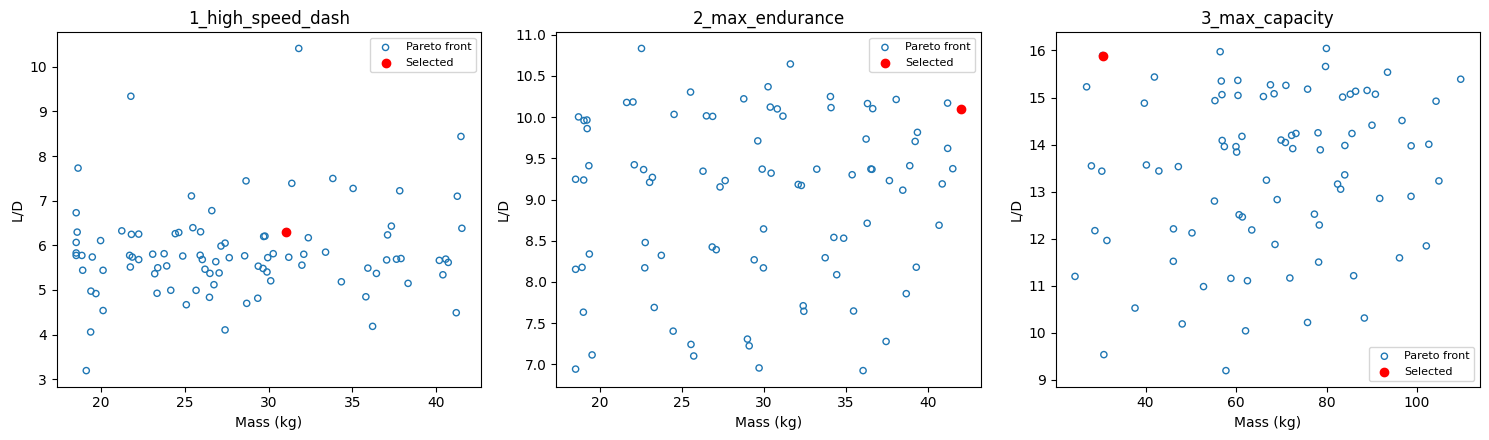

In [2]:
"""
BWB Inverse Design -- NSGA-III framework
Team: Inverse Huskies Pt.2

Info:

1. Runs once per test case (3 mission profiles), since the surrogates and
   targets are mission-dependent.
2. Selects the final design per case using the provided loss function applied to the feasible Pareto front.
3. Emits the "Output summary file" (CSV) the submission requires: one row
   per test case with the 21 design variables with the target values and loss.

Structural model note:

  FORWARD  (design -> performance): given a proposed x, predict
  Mass/Vp/Vf/Stress. This is what `Problem._evaluate()` needs every
  generation to rank candidates and check the 335 MPa constraint. Trained
  here as 4 independent XGBoost regressors on (planform + flight +
  structure) -> each output, mirroring the style of your notebook.

  INVERSE (performance -> design): Used to seed part of NSGA-III's initial population
"""

import os
import sys
import numpy as np
import pandas as pd

from pymoo.core.problem import Problem
from pymoo.core.repair import Repair
from pymoo.core.sampling import Sampling
from pymoo.algorithms.moo.nsga3 import NSGA3
from pymoo.util.ref_dirs import get_reference_directions
from pymoo.operators.crossover.sbx import SBX
from pymoo.operators.mutation.pm import PM
from pymoo.operators.sampling.lhs import LHS
from pymoo.termination import get_termination
from pymoo.optimize import minimize


# Paths

AERO_SURROGATE_DIR = "/content/drive/MyDrive/ASME Hackathon 2026/nTop---ASME-IDETC-CIE-Student-Hackathon/models/ld_surrogate"                    # contains predict_ld.py
STRUCTURES_CSV = "/content/drive/MyDrive/ASME Hackathon 2026/bwb_structures_dataset.csv"             # 13,720-row dataset
FORWARD_MODEL_CACHE = "structural_forward_surrogate.joblib"     # forward model cache (design -> perf)
INVERSE_MODEL_PATH = "/content/drive/MyDrive/ASME Hackathon 2026/bwb_inverse_design_models.joblib"          # your notebook's saved inverse models


# Design vector
PLANFORM_NAMES = [
    "C2/C1", "C3/C1", "C4/C1", "B1/C1", "B2/C1",
    "B3/C1", "X3/C1", "S1", "S3", "C1",
]
PLANFORM_BOUNDS = np.array([
    [0.55, 0.85],   # C2/C1
    [0.18, 0.28],   # C3/C1
    [0.06, 0.09],   # C4/C1
    [0.10, 0.20],   # B1/C1
    [0.05, 0.20],   # B2/C1
    [0.35, 0.70],   # B3/C1
    [0.50, 0.65],   # X3/C1
    [40.0, 60.0],   # S1 (deg)
    [20.0, 40.0],   # S3 (deg)
    [2500., 4000.], # C1 (mm, root chord scale)
])

STRUCTURE_NAMES = [
    "Skin Thickness", "Front Spar Chord %", "Rear Spar Chord %",
    "Spar Thickness", "# of Ribs", "Rib Thickness", "Wingbox Cutout",
    "# of Fuselage Ribs", "# of Fuselage Spars",
    "Fuselage Struct Thickness", "Fuselage Struct Width",
]
STRUCTURE_BOUNDS = np.array([
    [0.0003, 0.0050],  # Skin Thickness (m)
    [0.18, 0.35],       # Front Spar Chord % (frac)
    [0.55, 0.75],       # Rear Spar Chord % (frac)
    [0.00098, 0.0080],  # Spar Thickness (m)
    [3, 14],             # # of Ribs (int)
    [0.0015, 0.015],    # Rib Thickness (m)
    [0.01, 0.05],        # Wingbox Cutout (frac)
    [3, 11],              # # of Fuselage Ribs (ODD int only)
    [3, 12],              # # of Fuselage Spars (int)
    [0.002, 0.025],      # Fuselage Struct Thickness (m)
    [0.0010, 0.015],    # Fuselage Struct Width (m)
])

VAR_NAMES = PLANFORM_NAMES + STRUCTURE_NAMES
N_VAR = len(VAR_NAMES)  # 21

PLANFORM_IDX = list(range(0, 10))
STRUCTURE_IDX = list(range(10, 21))

XL = np.concatenate([PLANFORM_BOUNDS[:, 0], STRUCTURE_BOUNDS[:, 0]])
XU = np.concatenate([PLANFORM_BOUNDS[:, 1], STRUCTURE_BOUNDS[:, 1]])

# indices (within the full 21-length x) of the mixed-integer structural vars
IDX_N_RIBS = VAR_NAMES.index("# of Ribs")                # plain integer, 3-14
IDX_N_FUSELAGE_RIBS = VAR_NAMES.index("# of Fuselage Ribs")  # ODD integer, 3-11
IDX_N_FUSELAGE_SPARS = VAR_NAMES.index("# of Fuselage Spars")  # plain integer, 3-12

STRESS_MAX = 335.0   # MPa -- the true competition constraint; used for scoring_loss()
                      # and all reporting/CSV output, since that's what's actually graded.

# Safety margin applied ONLY to the optimizer's search constraint, not to scoring/
# reporting.
# This is because R2 values for stress are low and even if reported value without the margin is feasible the error is too much
SEARCH_STRESS_MAX = 275.0   # MPa -- used only in BWBInverseDesignProblem's constraint
M_REF = 50.0          # kg -- fixed normalizer used in the scoring loss (not a target)


# Mixed-integer repair
#snaps the variables that are set to integers as integers since NSGA-III doesn't automatically handle it
class MixedIntegerRepair(Repair):
    def _do(self, problem, X, **kwargs):
        X[:, IDX_N_RIBS] = np.round(X[:, IDX_N_RIBS])
        X[:, IDX_N_FUSELAGE_SPARS] = np.round(X[:, IDX_N_FUSELAGE_SPARS])

        # snap to nearest odd integer in [3, 11]
        odd_candidates = np.array([3, 5, 7, 9, 11])
        raw = X[:, IDX_N_FUSELAGE_RIBS].reshape(-1, 1)
        nearest_idx = np.abs(raw - odd_candidates.reshape(1, -1)).argmin(axis=1)
        X[:, IDX_N_FUSELAGE_RIBS] = odd_candidates[nearest_idx]

        return X


# Mission profiles
TEST_CASES = {
    "1_high_speed_dash": dict(
        altitude_kft=15, kcas=120, aoa_deg=1.0,
        ld_target=6.0, vp_target_m3=0.75, vf_target_m3=0.45,
    ),
    "2_max_endurance": dict(
        altitude_kft=15, kcas=45, aoa_deg=8.0,
        ld_target=10.0, vp_target_m3=0.80, vf_target_m3=0.45,
    ),
    "3_max_capacity": dict(
        altitude_kft=5, kcas=220, aoa_deg=4.5,
        ld_target=15.0, vp_target_m3=1.00, vf_target_m3=0.65,
    ),
}


# Surrogates

class AeroSurrogateCaller:
    """
    Vectorized aero surrogate call, replicating predict_ld_batch()'s math,
    using the 'full' checkpoint (reg_full.json)

    tracks how many evaluated rows fall outside the aero model's
    published trained envelope (Re_L, M_inf) each generation.
    """

    def __init__(self, surrogate_dir):
        sys.path.insert(0, surrogate_dir)
        import regressor as aero_reg
        import flight_conversion as FC
        self.FC = FC
        self.model, self.std = aero_reg.load("full")
        self._predict_raw = aero_reg.predict
        self.n_out_of_envelope = 0
        self.n_evaluated = 0

    def __call__(self, geom_batch, alt, kcas, aoa):
        FC = self.FC
        rows = np.asarray(geom_batch, dtype=np.float64)  # columns = PLANFORM_NAMES order
        # reorder from PLANFORM_NAMES to GEOM_ORDER_A (ratios..., S1, S3, C1) the module expects
        col_idx = [PLANFORM_NAMES.index(k) for k in FC.GEOM_ORDER_A]
        rows = rows[:, col_idx]

        scaled = rows[:, :9].copy()
        ratio_mask = np.array([k in FC.AERO_SCALED_KEYS for k in FC.GEOM_ORDER_A[:9]])
        # GEOM_ORDER_A[:9] happens to be the 6 ratios + S1,S3,X3/C1 in a specific order;
        # scale exactly the same subset predict_ld_batch scales (the 6 length ratios).
        scaled[:, ratio_mask] *= FC.AERO_C1_REF_MM
        C1 = rows[:, 9]

        fs = FC.convert(alt, kcas, aoa, C1_mm=1000.0)
        Re_coef = fs.rho * fs.V_true / (fs.mu * 1000.0)
        Re_L = Re_coef * C1
        M_inf = np.full_like(Re_L, fs.M_inf)
        alpha = np.full_like(Re_L, aoa)

        # reorder the 9 scaled geom columns from GEOM_ORDER_A[:9] to GEOM_ORDER_B
        # (the exact order the regressor was trained on)
        reorder = [FC.GEOM_ORDER_A[:9].index(k) for k in FC.GEOM_ORDER_B]
        geom9 = scaled[:, reorder]
        flight3 = np.column_stack([Re_L, M_inf, alpha])

        out = self._predict_raw(self.model, self.std, geom9, flight3)  # (N,2) = CL, CD
        l_over_d = out[:, 0] / out[:, 1]

        lo_re, hi_re = FC.RANGE_B["Re_L"]
        lo_m, hi_m = FC.RANGE_B["M_inf"]
        out_of_envelope = (Re_L < lo_re) | (Re_L > hi_re) | (M_inf < lo_m) | (M_inf > hi_m)
        self.n_out_of_envelope += int(out_of_envelope.sum())
        self.n_evaluated += len(rows)

        return l_over_d


def load_aero_surrogate(surrogate_dir=AERO_SURROGATE_DIR):
    """
    Loads the real aero surrogate via AeroSurrogateCaller

    Falls back to a dummy if the real module isn't found
    """
    if os.path.isdir(surrogate_dir):
        try:
            return AeroSurrogateCaller(surrogate_dir)
        except Exception as e:
            print(f"[warn] could not load real aero surrogate from {surrogate_dir} ({e}); using dummy aero surrogate")

    # --- dummy stand-in ---
    def dummy_call(geom_batch, alt, kcas, aoa):
        return 8 + 4 * np.sin(geom_batch.sum(axis=1)) + 0.01 * kcas - 0.05 * aoa
    return dummy_call


class ForwardSurrogateBundle:
    """Wraps 4 independent per-target XGBoost regressors (design -> one
    output each) behind a single `.predict(X) -> (n, 4)` interface

    All 4 targets (Mass, Vp, Vf, Stress) are strictly positive and heavily
    right-skewed in the real dataset (Mass skew=2.6, Stress skew=112 --
    a handful of huge designs dominate a plain squared-error fit). Each
    model is therefore trained on log1p(target) and inverted with expm1()
    at predict time .

   """

    TARGET_COLS = ["Aircraft Empty Weight", "Payload Volume", "Fuel Volume", "Max Hotspot Stress"]

    def __init__(self, models: dict, train_ranges: dict, range_margin=0.05):
        self.models = models              # {target_col: fitted regressor, trained on log1p(target)}
        self.train_ranges = train_ranges  # {target_col: (observed_min, observed_max)}
        self.range_margin = range_margin  # fractional margin allowed beyond the observed range
        self.n_clamped_negative = 0       # count: needed the >=0 physical floor
        self.n_clamped_out_of_range = 0   # count: needed the observed-training-range clamp

    def predict(self, X):
        raw_log = np.column_stack([self.models[col].predict(X) for col in self.TARGET_COLS])
        raw = np.expm1(raw_log)

        negative = raw < 0.0
        if negative.any():
            self.n_clamped_negative += int(negative.any(axis=1).sum())
        raw = np.clip(raw, 0.0, None)

        out = raw.copy()
        for j, col in enumerate(self.TARGET_COLS):
            lo, hi = self.train_ranges[col]
            # margin scaled off each bound itself, not the span -- with a
            # right-skewed target (mass min=19.5 but max=1639)
            lo_bound = max(0.0, lo * (1 - self.range_margin))
            hi_bound = hi * (1 + self.range_margin)
            out_of_range = (raw[:, j] < lo_bound) | (raw[:, j] > hi_bound)
            if out_of_range.any():
                self.n_clamped_out_of_range += int(out_of_range.sum())
            out[:, j] = np.clip(raw[:, j], lo_bound, hi_bound)

        return out


# Constraining the mass model to be monotonically non-decreasing in these columns keeps XGBoost
# from flipping sign when extrapolating toward the thin/few-ribs corner
# NSGA-III searches hardest. Direction is preserved under the log1p
# transform, .
# 1 = non-decreasing, 0 = unconstrained

MASS_MONOTONE_COLS = {
    "Skin Thickness": 1, "Spar Thickness": 1, "# of Ribs": 1, "Rib Thickness": 1,
    "# of Fuselage Ribs": 1, "# of Fuselage Spars": 1,
    "Fuselage Struct Thickness": 1, "Fuselage Struct Width": 1,
    # Chord-% and cutout variables trade material location, not amount added
    # -- direction isn't obviously monotonic, so left unconstrained (0):
    "Front Spar Chord %": 0, "Rear Spar Chord %": 0, "Wingbox Cutout": 0,
}


def train_or_load_structural_surrogate(csv_path=STRUCTURES_CSV, cache_path=FORWARD_MODEL_CACHE):
    """
    FORWARD surrogate: design -> performance. Fits (or loads a cached) set
    of 4 XGBoost regressors on the dataset, one per output:

        24 inputs (10 planform + 3 flight + 11 structural)
        -> Aircraft Empty Weight, Payload Volume, Fuel Volume, Max Hotspot Stress

    Each target is fit in log1p space (see ForwardSurrogateBundle) since
    all 4 are strictly positive and heavily right-skewed in this dataset.

    """
    feature_cols = PLANFORM_NAMES + ["Altitude", "KCAS", "AOA"] + STRUCTURE_NAMES

    if os.path.exists(cache_path):
        import joblib
        bundle = joblib.load(cache_path)
        return bundle, feature_cols

    if os.path.exists(csv_path):
        import xgboost as xgb
        import joblib

        df = pd.read_csv(csv_path)
        missing = [c for c in feature_cols + ForwardSurrogateBundle.TARGET_COLS if c not in df.columns]
        if missing:
            raise ValueError(f"CSV is missing expected columns: {missing}")

        X = df[feature_cols].values
        models = {}
        for col in ForwardSurrogateBundle.TARGET_COLS:
            kwargs = dict(
                n_estimators=300, max_depth=5, learning_rate=0.05,
                subsample=0.9, colsample_bytree=0.9, random_state=42, n_jobs=-1,
            )
            if col == "Aircraft Empty Weight":
                # monotone_constraints must be a tuple aligned 1:1 with feature_cols order
                kwargs["monotone_constraints"] = tuple(MASS_MONOTONE_COLS.get(c, 0) for c in feature_cols)
            model = xgb.XGBRegressor(**kwargs)
            model.fit(X, np.log1p(df[col].values))   # log1p: all 4 targets are positive & right-skewed
            models[col] = model

        train_ranges = {col: (float(df[col].min()), float(df[col].max())) for col in ForwardSurrogateBundle.TARGET_COLS}
        bundle = ForwardSurrogateBundle(models, train_ranges)
        joblib.dump(bundle, cache_path)
        print(f"[info] trained forward structural surrogate on {len(df)} rows, cached to {cache_path}")
        return bundle, feature_cols

    # --- dummy stand-in so this script runs without the real dataset ---
    print(f"[warn] {csv_path} not found; using dummy forward structural surrogate")

    class DummyStructuralSurrogate:
        def predict(self, X):
            struct = X[:, -11:]  # last 11 cols are the structural vars
            mass = 40 + 300 * struct[:, 0] + 50 * struct[:, 3] + 2.0 * struct[:, 4]
            vp = (0.5 + 0.4 * struct[:, 6]) * 1e9      # -> mm^3
            vf = (0.4 + 0.3 * struct[:, 6]) * 1e9      # -> mm^3
            stress = 150 + 40000 * struct[:, 0] + 3000 * struct[:, 3]
            return np.column_stack([mass, vp, vf, stress])

    return DummyStructuralSurrogate(), feature_cols


# Inverse model

INVERSE_FEATURE_COLS = ["Altitude", "KCAS", "AOA", "Payload Volume", "Fuel Volume", "Max Hotspot Stress"]
INVERSE_TARGET_COLS = PLANFORM_NAMES + STRUCTURE_NAMES + ["Aircraft Empty Weight"]
INVERSE_INTEGER_COLS = ["# of Ribs", "# of Fuselage Ribs", "# of Fuselage Spars"]


def load_inverse_design_models(path=INVERSE_MODEL_PATH):
    """Loads the dict of per-target models saved by
    flight_conditions_structure.ipynb

    Returns None if not found -- seeding then just falls back to
    fully-random initialization
    """
    if os.path.exists(path):
        import joblib
        return joblib.load(path)
    print(f"[warn] {path} not found; NSGA-III will use Latin Hypercube initialization only (no ML-seeded designs)")
    return None


def seed_designs_from_inverse_model(inverse_models, mission, n_seeds=20, stress_margin=20.0):
    """
    Queries the inverse model at several points near the mission's targets
    (Vp_target, Vf_target, and a stress value safely under the search
    constraint SEARCH_STRESS_MAX, with the mission's fixed flight
    condition) to get plausible starting design vectors. Perturbs the
    targets slightly per seed

    """
    if inverse_models is None:
        return np.empty((0, N_VAR))

    rng = np.random.default_rng(0)
    vp_mm3 = mission["vp_target_m3"] * 1e9
    vf_mm3 = mission["vf_target_m3"] * 1e9
    stress_query = SEARCH_STRESS_MAX - stress_margin  # aim comfortably under the search constraint

    rows = []
    for _ in range(n_seeds):
        jitter = rng.normal(1.0, 0.08, size=3)  # +-8% spread around each target
        row = {
            "Altitude": mission["altitude_kft"],
            "KCAS": mission["kcas"],
            "AOA": mission["aoa_deg"],
            "Payload Volume": vp_mm3 * jitter[0],
            "Fuel Volume": vf_mm3 * jitter[1],
            "Max Hotspot Stress": stress_query * jitter[2],
        }
        rows.append(row)
    query_df = pd.DataFrame(rows)
    query_df["Max Hotspot Stress"] = np.log1p(query_df["Max Hotspot Stress"])  # matches notebook's preprocessing
    X_query = query_df[INVERSE_FEATURE_COLS].values

    preds = {col: inverse_models[col].predict(X_query) for col in INVERSE_TARGET_COLS if col != "Aircraft Empty Weight"}
    seeds = np.column_stack([preds[name] for name in VAR_NAMES])  # VAR_NAMES = planform + structure order

    for j, name in enumerate(INVERSE_INTEGER_COLS):
        idx = VAR_NAMES.index(name)
        candidates = np.array([3, 5, 7, 9, 11]) if name == "# of Fuselage Ribs" else None
        if candidates is not None:
            nearest = np.abs(seeds[:, idx].reshape(-1, 1) - candidates.reshape(1, -1)).argmin(axis=1)
            seeds[:, idx] = candidates[nearest]
        else:
            seeds[:, idx] = np.round(seeds[:, idx])

    seeds = np.clip(seeds, XL, XU)
    return seeds


class SeededSampling(Sampling):
    """
    Fills part of the initial population with ML-seeded designs and fills the rest via
    Latin Hypercube Sampling

    """

    def __init__(self, seed_rows):
        super().__init__()
        self.seed_rows = seed_rows

    def _do(self, problem, n_samples, **kwargs):
        n_seed = min(len(self.seed_rows), n_samples)
        fill = LHS()._do(problem, n_samples - n_seed, **kwargs)
        if n_seed == 0:
            return fill
        return np.vstack([self.seed_rows[:n_seed], fill])


# Problem definition
#    4 objectives to minimize:
#      f1 = Mass
#      f2 = ReLU shortfall on L/D
#      f3 = ReLU shortfall on Vf
#      f4 = ReLU shortfall on Vp
#    1 constraint (hard):
#      g1 = Stress - 335 <= 0

class BWBInverseDesignProblem(Problem):
    def __init__(self, mission, aero_surrogate, structural_surrogate, struct_feature_cols):
        super().__init__(n_var=N_VAR, n_obj=4, n_constr=1, xl=XL, xu=XU)
        self.mission = mission
        self.aero_surrogate = aero_surrogate
        self.structural_surrogate = structural_surrogate
        self.struct_feature_cols = struct_feature_cols

    def _evaluate(self, X, out, *args, **kwargs):
        m = self.mission
        x_planform = X[:, PLANFORM_IDX]
        x_structure = X[:, STRUCTURE_IDX]

        # Planform -> L/D surrogate -> L/D
        l_over_d = self.aero_surrogate(x_planform, m["altitude_kft"], m["kcas"], m["aoa_deg"])

        # full feature row for the structural surrogate
        n = X.shape[0]
        flight_block = np.tile([m["altitude_kft"], m["kcas"], m["aoa_deg"]], (n, 1))
        struct_features = np.column_stack([x_planform, flight_block, x_structure])
        struct_out = self.structural_surrogate.predict(struct_features)
        mass, vp_mm3, vf_mm3, stress = (
            struct_out[:, 0], struct_out[:, 1], struct_out[:, 2], struct_out[:, 3]
        )
        vp_m3 = vp_mm3 / 1e9
        vf_m3 = vf_mm3 / 1e9

        # --- objectives: mass scaled to comparable order-of-magnitude to
        # the 0-1 shortfall terms; targets as one-sided ReLU shortfalls.

        f_mass = mass / M_REF
        f_ld = np.maximum(0.0, (m["ld_target"] - l_over_d) / m["ld_target"])
        f_vf = np.maximum(0.0, (m["vf_target_m3"] - vf_m3) / m["vf_target_m3"])
        f_vp = np.maximum(0.0, (m["vp_target_m3"] - vp_m3) / m["vp_target_m3"])
        out["F"] = np.column_stack([f_mass, f_ld, f_vf, f_vp])

        # hard constraint
        out["G"] = (stress - SEARCH_STRESS_MAX).reshape(-1, 1)

        # stash raw quantities for reporting
        out["l_over_d"] = l_over_d
        out["mass"] = mass
        out["vp_m3"] = vp_m3
        out["vf_m3"] = vf_m3
        out["stress"] = stress


# Loss Function
def scoring_loss(mass, l_over_d, vp_m3, vf_m3, stress, mission):
    ld_short = max(0.0, (mission["ld_target"] - l_over_d) / mission["ld_target"])
    vf_short = max(0.0, (mission["vf_target_m3"] - vf_m3) / mission["vf_target_m3"])
    vp_short = max(0.0, (mission["vp_target_m3"] - vp_m3) / mission["vp_target_m3"])
    stress_penalty = 0.0 if stress <= STRESS_MAX else 1e6 * max(0.0, stress - STRESS_MAX)
    return 0.4 * (mass / M_REF) + 0.2 * ld_short + 0.2 * vf_short + 0.2 * vp_short + stress_penalty


# Run NSGA-III for one test case

N_OBJ = 4  # mass, L/D-shortfall, Vf-shortfall, Vp-shortfall

# n_partitions=8 with 4 objectives gives C(11,3)=165 structured reference points spread evenly
# over the unit simplex; pop_size is set to match, per NSGA-III convention

REF_DIRS = get_reference_directions("das-dennis", N_OBJ, n_partitions=8)
NSGA3_POP_SIZE = len(REF_DIRS)


def run_case(case_name, mission, aero_surrogate, structural_surrogate, struct_feature_cols,
             inverse_models=None, pop_size=NSGA3_POP_SIZE, n_gen=250, seed=1):
    problem = BWBInverseDesignProblem(mission, aero_surrogate, structural_surrogate, struct_feature_cols)

    seed_rows = seed_designs_from_inverse_model(inverse_models, mission, n_seeds=max(20, pop_size // 5))
    sampling = SeededSampling(seed_rows) if len(seed_rows) > 0 else LHS()

    algorithm = NSGA3(
        ref_dirs=REF_DIRS,
        pop_size=pop_size,
        sampling=sampling,
        crossover=SBX(prob=0.9, eta=15),
        mutation=PM(eta=20),
        repair=MixedIntegerRepair(),
        eliminate_duplicates=True,
    )

    result = minimize(
        problem, algorithm, get_termination("n_gen", n_gen),
        seed=seed, save_history=False, verbose=False,
    )

    if result.X is None or len(result.X) == 0:
        print(f"[{case_name}] no feasible design found (stress <= {SEARCH_STRESS_MAX} MPa search margin never satisfied)")
        return None

    # re-evaluate the Pareto set to recover raw (non-normalized) quantities
    out = {}
    problem._evaluate(result.X, out)

    losses = np.array([
        scoring_loss(out["mass"][i], out["l_over_d"][i], out["vp_m3"][i], out["vf_m3"][i], out["stress"][i], mission)
        for i in range(len(result.X))
    ])
    best_idx = int(np.argmin(losses))

    print(f"[{case_name}] {len(result.X)} feasible Pareto designs | "
          f"best loss={losses[best_idx]:.4f}  Mass={out['mass'][best_idx]:.2f} kg  "
          f"L/D={out['l_over_d'][best_idx]:.2f} (target {mission['ld_target']})  "
          f"Vp={out['vp_m3'][best_idx]:.3f} m3 (target {mission['vp_target_m3']})  "
          f"Vf={out['vf_m3'][best_idx]:.3f} m3 (target {mission['vf_target_m3']})  "
          f"Stress={out['stress'][best_idx]:.1f} MPa")

    return dict(
        case=case_name,
        x=result.X[best_idx],
        mass=out["mass"][best_idx],
        l_over_d=out["l_over_d"][best_idx],
        vp_m3=out["vp_m3"][best_idx],
        vf_m3=out["vf_m3"][best_idx],
        stress=out["stress"][best_idx],
        loss=losses[best_idx],
        pareto_F=result.F,
        pareto_mass=out["mass"],
        pareto_ld=out["l_over_d"],
    )


# Main: run all 3 test cases, write the submission's output summary CSV

if __name__ == "__main__":
    aero_surrogate = load_aero_surrogate()
    structural_surrogate, struct_feature_cols = train_or_load_structural_surrogate()
    inverse_models = load_inverse_design_models()

    rows = []
    fig_data = []
    for case_name, mission in TEST_CASES.items():
        res = run_case(case_name, mission, aero_surrogate, structural_surrogate, struct_feature_cols,
                        inverse_models=inverse_models)
        if res is None:
            continue
        row = {"case": res["case"]}
        row.update({name: val for name, val in zip(VAR_NAMES, res["x"])})
        row.update({
            "Mass_kg": res["mass"], "L_over_D": res["l_over_d"],
            "Vp_m3": res["vp_m3"], "Vf_m3": res["vf_m3"],
            "Stress_MPa": res["stress"], "Loss": res["loss"],
        })
        rows.append(row)
        fig_data.append((case_name, res["pareto_mass"], res["pareto_ld"], res["mass"], res["l_over_d"]))

    summary = pd.DataFrame(rows)
    summary.to_csv("output_summary.csv", index=False)
    print("\nSaved output_summary.csv")
    print(summary[["case", "Mass_kg", "L_over_D", "Vp_m3", "Vf_m3", "Stress_MPa", "Loss"]].to_string(index=False))

    if hasattr(structural_surrogate, "n_clamped_negative") and (
        structural_surrogate.n_clamped_negative > 0 or structural_surrogate.n_clamped_out_of_range > 0
    ):
        print(f"\n[warn] forward surrogate needed clamping across the run: "
              f"{structural_surrogate.n_clamped_negative} evaluation(s) went negative (physical floor), "
              f"{structural_surrogate.n_clamped_out_of_range} evaluation(s) fell outside the observed "
              f"training range (data-envelope guard). This means NSGA-III is spending time in a region "
              f"the model is extrapolating in -- worth tightening XL/XU or adding more training data "
              f"near that corner if these numbers are large.")

    if hasattr(aero_surrogate, "n_out_of_envelope") and aero_surrogate.n_out_of_envelope > 0:
        pct = 100.0 * aero_surrogate.n_out_of_envelope / max(1, aero_surrogate.n_evaluated)
        print(f"\n[warn] aero surrogate: {aero_surrogate.n_out_of_envelope} / {aero_surrogate.n_evaluated} "
              f"evaluations ({pct:.2f}%) fell outside the trained Re_L/M_inf envelope "
              f"(models/ld_surrogate/flight_conversion.py RANGE_B). Predicted L/D at those points is "
              f"extrapolation.")

    # Pareto front plots: mass vs L/D per case
    try:
        import matplotlib.pyplot as plt
        fig, axes = plt.subplots(1, len(fig_data), figsize=(5 * len(fig_data), 4.5), squeeze=False)
        for ax, (case_name, mass, ld, sel_mass, sel_ld) in zip(axes[0], fig_data):
            ax.scatter(mass, ld, s=20, facecolors="none", edgecolors="tab:blue", label="Pareto front")
            ax.scatter(sel_mass, sel_ld, color="red", zorder=5, label="Selected")
            ax.set_xlabel("Mass (kg)")
            ax.set_ylabel("L/D")
            ax.set_title(case_name)
            ax.legend(fontsize=8)
        plt.tight_layout()
        plt.savefig("pareto_fronts.png", dpi=150)
        print("Saved pareto_fronts.png")
    except ImportError:
        pass